In [91]:
from IPython.display import HTML
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Montserrat:ital,wght@0,300;0,400;0,700;1,400&display=swap');
</style>
"""))

REDUIRE A 15 CLASSES SUR LE SOL !

<h1 style="color:teal; font-size:45px; font-family:'Montserrat', sans-serif; font-weight:bold; margin-bottom: 5px;">
Notebook SENTINEL-2 - PIR Rio Tinto
</h1>

<p style="color:#444; font-size:12px; font-family:'Montserrat', sans-serif; border-bottom: 3px solid #2980b9; padding-bottom: 10px; font-weight:bold; margin-top: 0px;">
Data : EnMAP Image
</p>
<p style="font-size:16px; font-family:'Montserrat'; color:#34495e; margin-top: 0px; text-align: right;">
HOSSEINI Arman, STAUB Guillaume
</p>

<div style="margin-top: 30px;">
</div>
<div style="background-color: #ecf5fb; border-left: 15px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
<h2 style="color: teal; ">Index</h2>
<ul style="list-style-type: none; padding-left: 0;">
    <li style="margin-bottom: 8px;">
            <a href="#00" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">0.</span>
                <span style="color: #2c3e50; font-weight: 600;">Imports</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#10" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">1.</span>
                <span style="color: #2c3e50; font-weight: 600;">Visualization</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#20" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">2.</span>
                <span style="color: #2c3e50; font-weight: 600;">Direct K-Means</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#30" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">3.</span>
                <span style="color: #2c3e50; font-weight: 600;">Pixel-by-Pixel AutoEncoder with K-Means on latent-space</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#40" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">4.</span>
                <span style="color: #2c3e50; font-weight: 600;">2D Convolutional AutoEncoder with K-Means on latent space</span>
            </a>
        </li>
    <!--
    <ul style="list-style-type: circle; padding-left: 60px;">
        <li><a href="#21" style="color:#2c3e50; text-decoration: none;">2.1 </a></li>
    </ul>
    -->
</ul>
</div>
<div id="00"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; margin-top: 30px; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    0. Imports
</h2>

In [92]:
import time
import os

import sys, random, re

import torch; import torch.nn as nn; import torch.nn.functional as F
from torch.utils.data import TensorDataset, Dataset, DataLoader, Subset

import rasterio as rio; from rasterio.plot import reshape_as_image, reshape_as_raster
import numpy as np; import pandas as pd
from sklearn.preprocessing import StandardScaler; from sklearn.cluster import KMeans; from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score
import matplotlib.pyplot as plt; import matplotlib.colors as colors; from matplotlib.colors import ListedColormap
from matplotlib import cm
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster; from kneed import KneeLocator
import xml.etree.ElementTree as ET
from tqdm import tqdm
from sklearn.manifold import TSNE
import seaborn as sns

<div id="10"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    1. Visualization

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We start by applying masks to the SENTINEL-2 image and display them.

In [93]:
def apply_mask(image_path, mask_path):
    # --- Image ---
    raster_img = rio.open(image_path)
    arr_img = reshape_as_image(raster_img.read())  # (m, n, l)

    # On ne met NaN que pour les pixels hors [0,1] (les zéros restent)
    mask_norm = np.all((arr_img >= 0) & (arr_img <= 1), axis=2)
    arr_img[~mask_norm] = np.nan

    image = reshape_as_raster(arr_img)
    l, m, n = image.shape

    X = image.reshape(l, -1).T
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- Masque ---
    with rio.open(mask_path) as src:
        mask_band = src.read(1)                 # (m, n)
    mask_soil = (mask_band > 0).astype(np.uint8)  # 1 = zone affichée, 0 = fond

    mask_soil_elargi = mask_soil[:, :, np.newaxis]          # (m, n, 1)
    vec_new = np.repeat(mask_soil_elargi, X_scaled.shape[1], axis=2)  # (m, n, l)

    X_scaled_soil = X_scaled.reshape(m, n, l) * vec_new

    # --- RGB ---
    RED   = X_scaled_soil[:, :, 2]
    GREEN = X_scaled_soil[:, :, 1]
    BLUE  = X_scaled_soil[:, :, 0]
    rgb = np.stack([RED, GREEN, BLUE], axis=-1)   # (m, n, 3)

    # --- Normalisation canal par canal ---
    min_val = np.nanmin(rgb, axis=(0, 1))
    max_val = np.nanmax(rgb, axis=(0, 1))
    scale = max_val - min_val
    scale[scale == 0] = 1
    rgb_norm = (rgb - min_val) / scale

    # --- FORCER le fond à noir ---
    # mask_soil == 0 -> fond, on les met à (0,0,0)
    fond = (mask_soil == 0)           # (m, n) bool
    rgb_norm[fond] = 0.0              # broadcasting sur la 3ème dimension

    plt.imshow(rgb_norm)
    plt.axis('off')
    plt.show()

    return rgb_norm, fond

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
SENTINEL-2 image with mask to only display the soil:

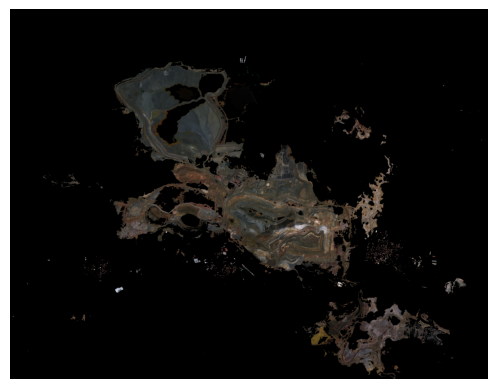

In [94]:
soil_only, fond_soil = apply_mask(r'./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_FRE_extrait_stack_gain_10m.img',
                       r"./mask_total_soil_VSWIR_10m.img")

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
EnMAP image with mask to only display the vegetation:

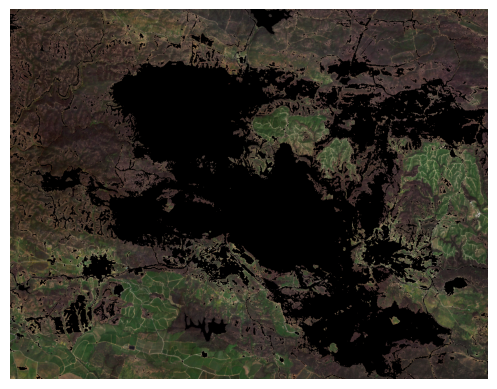

In [95]:
vegetation_only, fond_vegetation = apply_mask(r'./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_FRE_extrait_stack_gain_10m.img',
                             r"./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_mask_veg.img")

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We apply the vegetation mask and set all external pixels to the mean of the scaled vegetation pixel values:

In [96]:
image_path = r'./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_FRE_extrait_stack_gain_10m.img'
raster_img = rio.open(image_path)
arr_img = reshape_as_image(raster_img.read())  # (m, n, l)
image = reshape_as_raster(arr_img)
l, m, n = image.shape

veg_mask_2d = (vegetation_only[:, :, 0] != 0)  # prendre la première bande uniquement
veg_mask_1d = veg_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
veg_pixels = pixels[veg_mask_1d]             # (N_veg, l) → uniquement végétation

scaler = StandardScaler()
X_scaled_veg = scaler.fit_transform(veg_pixels)
#print(X_scaled_veg.shape)
img_scaled_veg_complete = pixels.copy()
img_scaled_veg_complete[veg_mask_1d] = X_scaled_veg
img_scaled_veg_complete[~veg_mask_1d] = np.mean(X_scaled_veg)

<div id="20"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    2. Direct K-Means 

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We will use the knee criterion to guess the number of clusters we want for vegetation, soil and "other" separately:

<div id="21"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.1 Vegetation (and partial ARI)

In [97]:
def compute_optimal_k(X_scaled):

    inertias = []
    K_range = range(2, 20, 1)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
        #print("Done")
    
    plt.plot(K_range, inertias, marker='o')
    plt.xlabel('Number of clusters K')
    plt.ylabel('Inertia (Sum of distances)')
    plt.title('Knee criterion')
    plt.show()
    
    knee = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
    optimal_k = knee.knee
    
    print(f"optimal value: k = {optimal_k}")
    
    return optimal_k

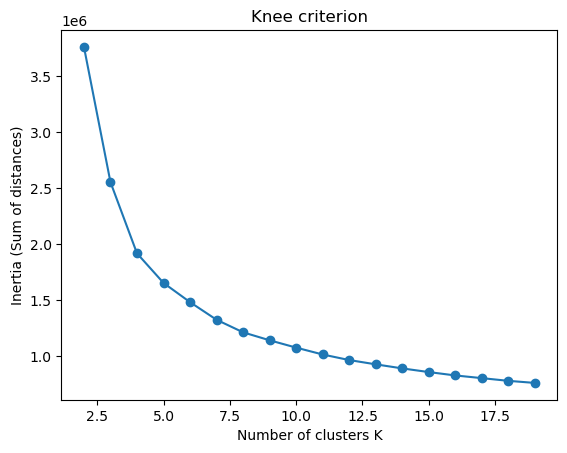

optimal value: k = 5


In [98]:
optimal_k_veg = compute_optimal_k(X_scaled_veg)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We apply K-Means and display the mean spectrum for each cluster. We also compute the Silhouette score as well as the Calinski-Harabasz Index.

In [163]:
def KMeans_mean_spectra(X_scaled, mask_1D, optimal_k, bands_number, max_samples=10000):
    kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
    labels = kmeans_final.fit_predict(X_scaled)
    
    n_samples = X_scaled.shape[0]
    
    if n_samples > max_samples:
        idx = np.random.choice(n_samples, max_samples, replace=False)
        X_sampled = X_scaled[idx]
        labels_sampled = labels[idx]
    else:
        X_sampled = X_scaled
        labels_sampled = labels
    
    sil_score = silhouette_score(X_sampled, labels_sampled)
    
    print(f"Silhouette (sampled) for k = {optimal_k} : {sil_score:.3f}")
    
    # Calcul des moyennes par cluster
    mean_spectra = np.zeros((optimal_k, bands_number))
    std_spectra = np.zeros((optimal_k, bands_number))
    
    for k in range(optimal_k):
        cluster_pixels = pixels[mask_1D][labels == k]
        mean_spectra[k] = cluster_pixels.mean(axis=0)
        std_spectra[k]  = cluster_pixels.std(axis=0)
    
    # Option : afficher sous forme de tableau avec pandas
    df_mean_spectra = pd.DataFrame(
        mean_spectra, 
        columns=[f'Bande_{i+1}' for i in range(bands_number)]
    )
    df_mean_spectra.index = [f'Cluster_{i+1}' for i in range(optimal_k)]
    
    plt.figure(figsize=(8,5))
    bands = np.array([492, 559, 664, 703, 739, 779, 832, 864, 1610,  2185])
    
    for k in range(optimal_k):
        plt.plot(bands, mean_spectra[k], label=f'Cluster {k+1}')
        plt.fill_between(
            bands,
            mean_spectra[k] - std_spectra[k],
            mean_spectra[k] + std_spectra[k],
            alpha=0.2
        )
    plt.xlabel('Wavelength')
    plt.ylabel('Average value')
    plt.title('Mean spectrum by cluster')
    plt.legend()
    plt.show()
    return labels

Silhouette (sampled) for k = 5 : 0.341


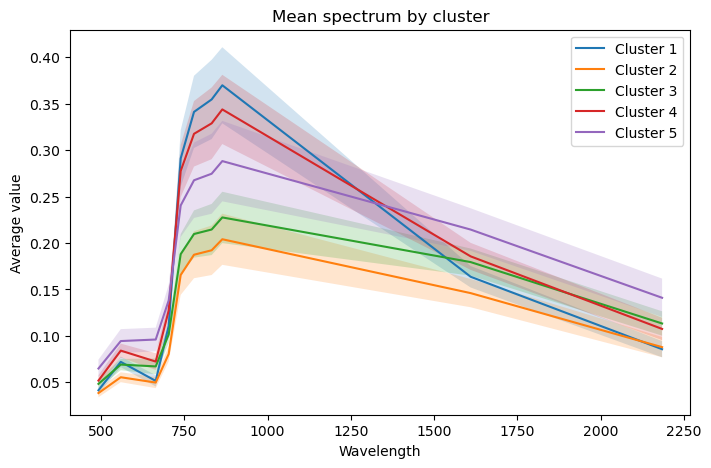

In [164]:
labels_veg = KMeans_mean_spectra(X_scaled_veg, veg_mask_1d, optimal_k_veg, l)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
Then, We can display the map with clustered vegetation. Masked pixels are displayed in black.

In [165]:
def display_clusters(mask_2D, labels, optimal_k):
    # --- 7) Construction de la carte finale ---
    cluster_map = np.zeros((m, n), dtype=int)
    cluster_map[mask_2D] = labels + 1  # 0 = fond, clusters à partir de 1
    
    # --- 8) Création de la colormap ---
    cmap_colors = ["black"] + list(plt.cm.tab10.colors[:optimal_k])
    cmap = colors.ListedColormap(cmap_colors)
    
    # --- 9) Affichage ---
    plt.figure(figsize=(10,10))
    plt.imshow(cluster_map, cmap=cmap)
    plt.axis('off')
    #plt.title("Clusters of vegetation")
    plt.show()

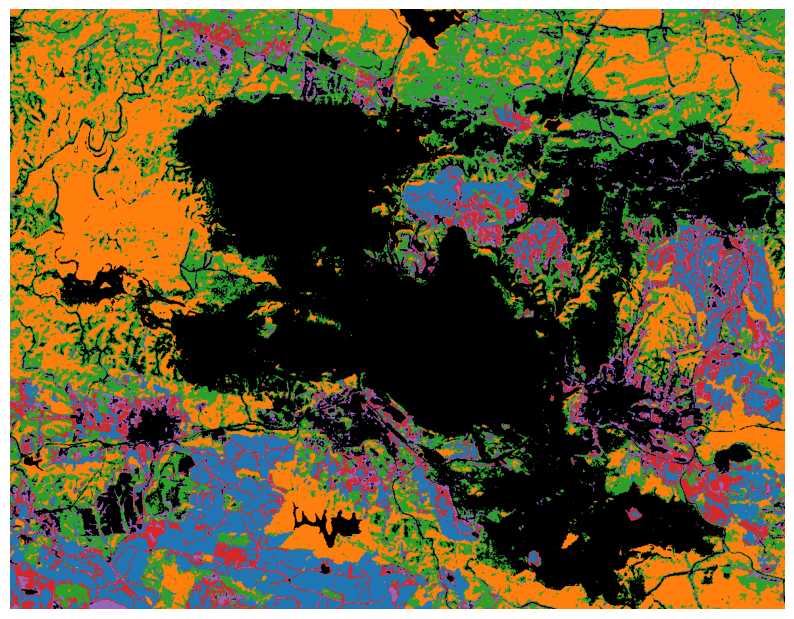

In [166]:
display_clusters(veg_mask_2d, labels_veg, optimal_k_veg)

In [167]:
# Chemins de fichiers (à adapter)
path_ground_truth = 'CS3_HandMadeSAM_lbl.img'

# 1. Lecture de la ground truth
with rio.open(path_ground_truth) as src_gt:
    ground_truth_array = src_gt.read(1)  # Lire la première (et unique) bande

# 2. Création du masque
# 'valid_pixels_mask' est VRAI là où il y a une étiquette de classe valide (> 0)
valid_pixels_mask = ground_truth_array > 0

# ground_truth_labels contient maintenant uniquement les étiquettes valides pour la comparaison
ground_truth_labels = ground_truth_array[valid_pixels_mask]

X_cluster = np.zeros((m,n))
X_cluster[veg_mask_2d] = labels_veg

# 4. Extraction des résultats de clustering pour les pixels valides
# On applique le même masque au résultat du clustering
cluster_labels_for_comparison = X_cluster[valid_pixels_mask]

# Calcul de l'Adjusted Rand Index
ari_score = adjusted_rand_score(
    labels_true=ground_truth_labels, 
    labels_pred=cluster_labels_for_comparison
)

print(f"The partial Adjusted Rand Index (ARI) on vegetation with Direct K-means is : {ari_score:.4f}")

The partial Adjusted Rand Index (ARI) on vegetation with Direct K-means is : 0.4517


<div id="22"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.2 Soil

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We compute the 1D and 2D masks for the soil.

In [168]:
soil_mask_2d = (soil_only[:, :, 0] != 0)  # prendre la première bande uniquement
soil_mask_1d = soil_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = image.reshape(l, -1).T   
soil_pixels = pixels[soil_mask_1d]     

scaler = StandardScaler()
X_scaled_soil = scaler.fit_transform(soil_pixels)

img_scaled_soil_complete = pixels.copy()
img_scaled_soil_complete[soil_mask_1d] = X_scaled_soil
img_scaled_soil_complete[~soil_mask_1d] = np.mean(X_scaled_soil)


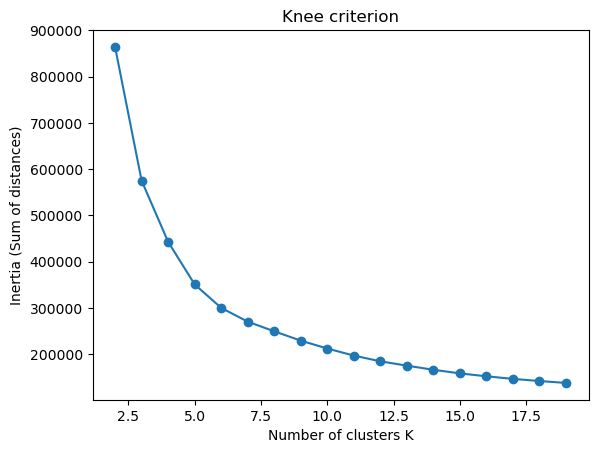

optimal value: k = 6


In [169]:
optimal_k_soil = compute_optimal_k(X_scaled_soil)

<div style="background-color: #f6bcb2; border-left: 5px solid #ff0000; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: 2d3436;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We decide to not use the optimal k for soil due to external knowledge, using k = 15 instead. 

In [171]:
optimal_k_soil = 15

Silhouette (sampled) for k = 15 : 0.237


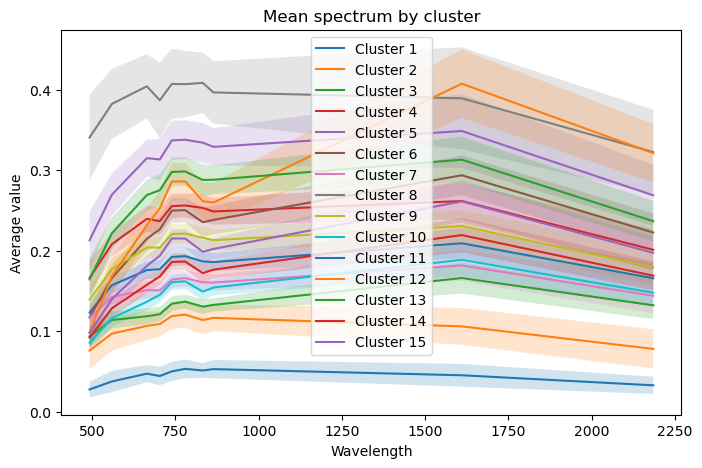

In [172]:
labels_soil = KMeans_mean_spectra(X_scaled_soil, soil_mask_1d, optimal_k_soil, l)

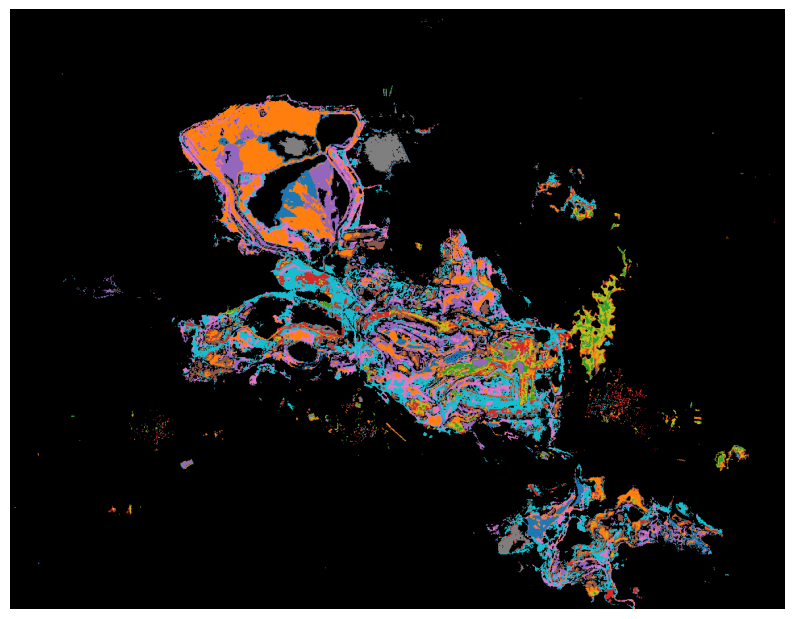

In [173]:
display_clusters(soil_mask_2d, labels_soil, optimal_k_soil)

<div id="23"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.3 Other

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We compute the 1D and 2D masks for the rest.

In [174]:
other_mask_2d = (soil_only[:, :, 0] == 0) & (vegetation_only[:,:,0]== 0)  # prendre la première bande uniquement
other_mask_1d = other_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
other_pixels = pixels[other_mask_1d]             

scaler = StandardScaler()
X_scaled_other = scaler.fit_transform(other_pixels)

img_scaled_other_complete = pixels.copy()
img_scaled_other_complete[other_mask_1d] = X_scaled_other
img_scaled_other_complete[~other_mask_1d] = np.mean(X_scaled_other)

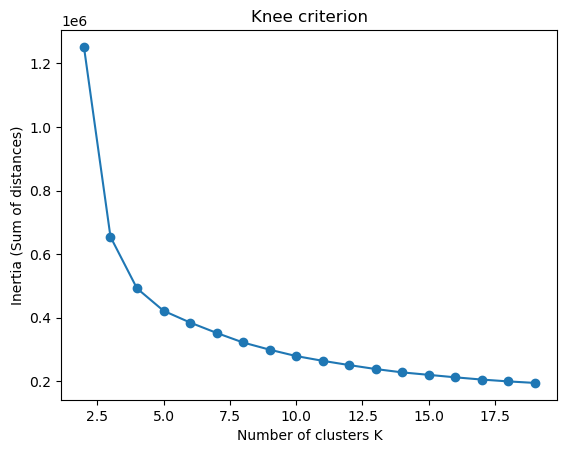

optimal value: k = 5


In [175]:
optimal_k_other = compute_optimal_k(X_scaled_other)

Silhouette (sampled) for k = 5 : 0.305


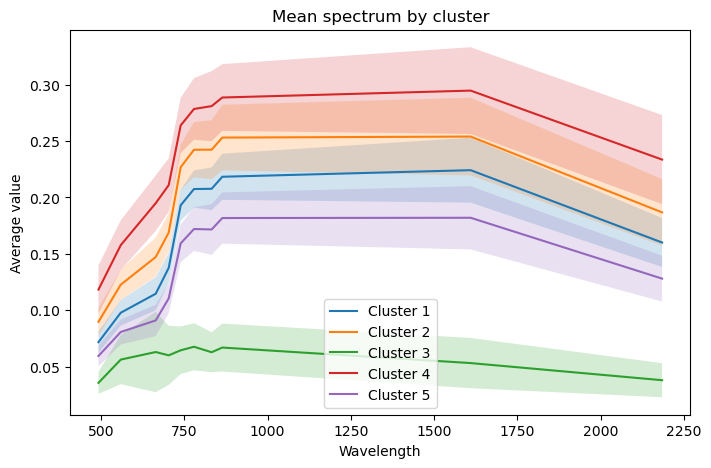

In [176]:
labels_other = KMeans_mean_spectra(X_scaled_other, other_mask_1d, optimal_k_other, l)

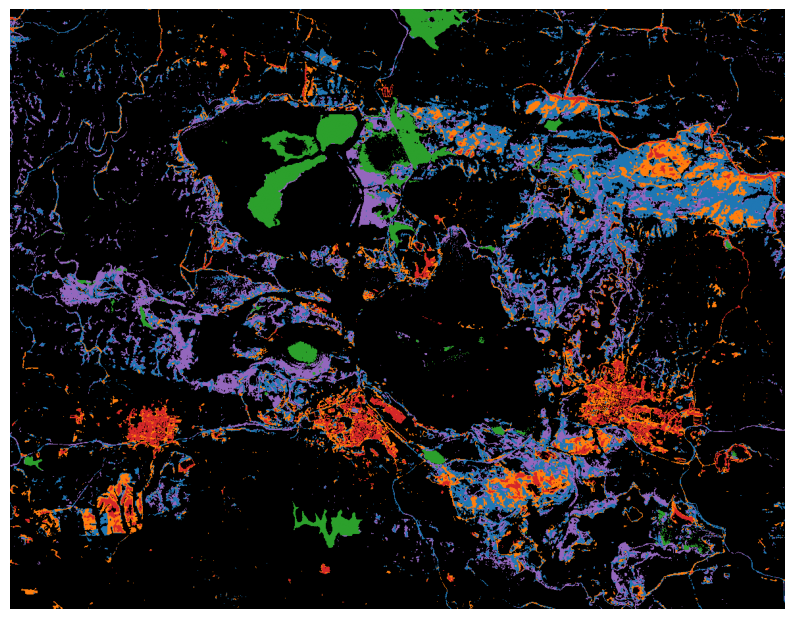

In [177]:
display_clusters(other_mask_2d, labels_other, optimal_k_other)

<div id="30"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    3. Pixel-by-Pixel AutoEncoder with K-Means on latent-space

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We first try an AutoEncoder which takes separately each pixel and gives a latent representation. We then apply the K-means algorithm on these representations with the values of "optimal K" obtained precedently.

In [228]:
class PbPAutoencoder(nn.Module):
    def __init__(self, in_dim, latent_dim, dropout_rate=0.2):
        super().__init__()

        # Hyperparamètres
        self.latent_dim = latent_dim

        # ----- Encodeur -----
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.LayerNorm(256),
            nn.Dropout(dropout_rate), # Régularisation
            
            # 2. Deuxième couche : Compression intermédiaire
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(True),
            
            # 3. Troisième couche (Couche latente)
            nn.Linear(128, latent_dim)
        )

        # ----- Décodeur -----
        self.decoder = nn.Sequential(
            # 1. Premiére couche : Décompression intermédiaire
            nn.Linear(latent_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            
            # 2. Deuxième couche : Décompression avancée
            nn.Linear(128, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            
            # 3. Dernière couche : Reconstruction de l'entrée
            nn.Linear(256, in_dim),
            #nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec, z

In [229]:
def encode_all(model, dataloader, device):
    model.eval()
    latents = []

    with torch.no_grad():
        for x, in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

In [230]:
def train_PbP_autoencoder(LATENT_DIM, EPOCHS, X_scaled, n_clusters, max_samples = 10000):

    BANDS = l                    # nb de bandes spectrales
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    dataset = TensorDataset(X_tensor.T.reshape(l, -1).T)
    loader = DataLoader(dataset, batch_size=1024, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size=1024, shuffle=False)

    # ------------------------------------------------------------------
    # Autoencodeur
    # ------------------------------------------------------------------
    model = PbPAutoencoder(BANDS, LATENT_DIM).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Entraînement
    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0
        for x, in loader:
            x = x.to(DEVICE)

            out, _ = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

        print(f"Epoch {ep+1}/{EPOCHS}   Loss = {loss_sum/len(loader):.6f}")

    # ------------------------------------------------------------------
    # Extraction du latent
    # ------------------------------------------------------------------
    model.eval()

    latent_vectors = []
    with torch.no_grad():
        for (x,) in loader_ordered:
            x = x.to(DEVICE)
            _, z = model(x)
            latent_vectors.append(z.cpu().numpy())
            
    latent_vectors = np.concatenate(latent_vectors, axis=0)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    kmeans = KMeans(n_clusters, n_init=50, random_state=0)
    labels_1d = kmeans.fit_predict(latent_vectors)

    # Échantillonnage pour le score (car trop lourd sur tous les pixels)
    if X_scaled.shape[0] > max_samples:
        idx = np.random.choice(X_scaled.shape[0], max_samples, replace=False)
        X_sample = X_scaled[idx]
        labels_sample = labels_1d[idx]
    else:
        X_sample = X_scaled
        labels_sample = labels_1d

    # Silhouette "Latente" (Espace du modèle) -> Séparabilité vue par le réseau
    sil_score = silhouette_score(X_sample, labels_sample)

    print(f"Silhouette (échantillon) pour k = {n_clusters} : {sil_score:.3f}")

    return labels_1d

In [116]:
def get_n_colors(n):
    base = plt.cm.get_cmap("tab20")   # ou "nipy_spectral", "viridis", etc.
    colors = base(np.linspace(0, 1, n))
    return colors.ListedColormap(colors)

<div id="31"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.1 Vegetation (and partial ARI)

In [231]:
LATENT_DIM = 4
N_EPOCHS = 25

labels_1d_veg = train_PbP_autoencoder(LATENT_DIM, N_EPOCHS, X_scaled_veg, optimal_k_veg)

Epoch 1/25   Loss = 0.038609
Epoch 2/25   Loss = 0.016460
Epoch 3/25   Loss = 0.015198
Epoch 4/25   Loss = 0.014772
Epoch 5/25   Loss = 0.014352
Epoch 6/25   Loss = 0.014107
Epoch 7/25   Loss = 0.013903
Epoch 8/25   Loss = 0.013686
Epoch 9/25   Loss = 0.013601
Epoch 10/25   Loss = 0.013384
Epoch 11/25   Loss = 0.013301
Epoch 12/25   Loss = 0.013158
Epoch 13/25   Loss = 0.013055
Epoch 14/25   Loss = 0.012944
Epoch 15/25   Loss = 0.012848
Epoch 16/25   Loss = 0.012684
Epoch 17/25   Loss = 0.012595
Epoch 18/25   Loss = 0.012462
Epoch 19/25   Loss = 0.012361
Epoch 20/25   Loss = 0.012251
Epoch 21/25   Loss = 0.012166
Epoch 22/25   Loss = 0.012029
Epoch 23/25   Loss = 0.011924
Epoch 24/25   Loss = 0.011885
Epoch 25/25   Loss = 0.011745
Silhouette (échantillon) pour k = 5 : 0.257


In [232]:
X_cluster = np.zeros((m,n))
X_cluster[veg_mask_2d] = labels_1d_veg

# 4. Extraction des résultats de clustering pour les pixels valides
# On applique le même masque au résultat du clustering
cluster_labels_for_comparison = X_cluster[valid_pixels_mask]

# Calcul de l'Adjusted Rand Index
ari_score = adjusted_rand_score(
    labels_true=ground_truth_labels, 
    labels_pred=cluster_labels_for_comparison
)

print(f"The partial Adjusted Rand Index (ARI) on vegetation with PbP Autoencoder + K-means on latent space is : {ari_score:.4f}")

The partial Adjusted Rand Index (ARI) on vegetation with PbP Autoencoder + K-means on latent space is : 0.4578


<div id="32"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.2 Soil

In [233]:
train_PbP_autoencoder(LATENT_DIM, N_EPOCHS, X_scaled_soil, optimal_k_soil)

Epoch 1/25   Loss = 0.077088
Epoch 2/25   Loss = 0.021883
Epoch 3/25   Loss = 0.019409
Epoch 4/25   Loss = 0.017512
Epoch 5/25   Loss = 0.013181
Epoch 6/25   Loss = 0.012299
Epoch 7/25   Loss = 0.012159
Epoch 8/25   Loss = 0.011725
Epoch 9/25   Loss = 0.011448
Epoch 10/25   Loss = 0.011269
Epoch 11/25   Loss = 0.011028
Epoch 12/25   Loss = 0.011115
Epoch 13/25   Loss = 0.010754
Epoch 14/25   Loss = 0.010753
Epoch 15/25   Loss = 0.010622
Epoch 16/25   Loss = 0.010667
Epoch 17/25   Loss = 0.010446
Epoch 18/25   Loss = 0.010368
Epoch 19/25   Loss = 0.010259
Epoch 20/25   Loss = 0.010257
Epoch 21/25   Loss = 0.010110
Epoch 22/25   Loss = 0.010149
Epoch 23/25   Loss = 0.010093
Epoch 24/25   Loss = 0.010153
Epoch 25/25   Loss = 0.009876
Silhouette (échantillon) pour k = 15 : 0.167


array([ 4,  4,  4, ...,  2,  8, 14], shape=(171907,), dtype=int32)

<div id="33"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.3 Other

In [234]:
train_PbP_autoencoder(LATENT_DIM, N_EPOCHS, X_scaled_other, optimal_k_other)

Epoch 1/25   Loss = 0.063983
Epoch 2/25   Loss = 0.018323
Epoch 3/25   Loss = 0.014733
Epoch 4/25   Loss = 0.013936
Epoch 5/25   Loss = 0.013250
Epoch 6/25   Loss = 0.012821
Epoch 7/25   Loss = 0.012474
Epoch 8/25   Loss = 0.012206
Epoch 9/25   Loss = 0.012067
Epoch 10/25   Loss = 0.011899
Epoch 11/25   Loss = 0.011638
Epoch 12/25   Loss = 0.011401
Epoch 13/25   Loss = 0.011363
Epoch 14/25   Loss = 0.011171
Epoch 15/25   Loss = 0.011163
Epoch 16/25   Loss = 0.010960
Epoch 17/25   Loss = 0.010878
Epoch 18/25   Loss = 0.010721
Epoch 19/25   Loss = 0.010702
Epoch 20/25   Loss = 0.010554
Epoch 21/25   Loss = 0.010543
Epoch 22/25   Loss = 0.010421
Epoch 23/25   Loss = 0.010326
Epoch 24/25   Loss = 0.010286
Epoch 25/25   Loss = 0.010237
Silhouette (échantillon) pour k = 5 : 0.270


array([4, 1, 4, ..., 4, 2, 4], shape=(234214,), dtype=int32)

<div id="40"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    4. 2D Convolutional AutoEncoder with K-Means on latent space

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
As our non-Convolutional AE provides poor results, we will now focus on Convolutional Autoencoders. We apply the K-means algorithm on the latent representation of patches (16*16 pixels for instance). To "propagate" the classification information, there are different options. 

In [268]:
LATENT_DIM = 4
EPOCHS = 20
PATCH_SIZE = 5
STRIDE = 3 # pour l'apprentissage
BATCH_SIZE = 256
VEG_THRESHOLD = 0.8

In [269]:
class ConvAutoencoder(nn.Module):
    def __init__(self, in_channels, latent_dim=LATENT_DIM):
        """
        in_channels : nombre de canaux de l'image
        latent_dim  : taille du vecteur latent
        input_size  : taille de l'image d'entrée (supposé carré)
        """
        super(ConvAutoencoder, self).__init__()

        self.latent_dim = latent_dim

        # ------- ENCODER -------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=0),
            nn.GroupNorm(8, 64), 
            nn.ReLU(True),

            nn.Conv2d(64, 128, 3, stride=1, padding=0),          # H/8
            nn.ReLU(True)
        )
        
        self.fc_enc = nn.Linear(128, self.latent_dim)  # on initialisera dynamiquement au premier forward
        self.fc_dec = nn.Linear(self.latent_dim, 128)

        # ------- DECODER -------
        self.decoder_conv = nn.Sequential(

            nn.ConvTranspose2d(128, 64, 3, stride=1, padding=0),
            nn.GroupNorm(8,64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, in_channels, 3, stride=1, padding=0),  # H*2
            #nn.Sigmoid() On veut pouvoir reconstruire des valeurs négatives : standard scaling
        )

    def forward(self, x):
        # Encoder
        z = self.encoder_conv(x)
        z_flat = z.view(z.size(0), -1)        # Flatten
        z_latent = self.fc_enc(z_flat)                # Latent vector

        # Decoder
        z_dec = self.fc_dec(z_latent)
        z_dec = z_dec.view(z_dec.size(0), 128, 1, 1)
        x_recon = self.decoder_conv(z_dec)

        return x_recon, z_latent
    
    def encode(self, x):
        z = self.encoder_conv(x)
        z_flat = z.view(z.size(0), -1)
        z_latent = self.fc_enc(z_flat)
        return z_latent

In [270]:
def fill_invalid_pixels_with_mean(x_batch, mask_batch):
    """
    x_batch: (B, C, H, W)
    mask_batch: (B, H, W) avec 0 / 1
    """

    mask = mask_batch.unsqueeze(1)  # (B,1,H,W)

    # nombre de pixels valides par patch
    valid_count = mask.sum(dim=(2, 3), keepdim=True).clamp(min=1)

    # moyenne par canal et par patch
    mean_vals = (x_batch * mask).sum(dim=(2, 3), keepdim=True) / valid_count

    # remplacement
    x_filled = x_batch * mask + mean_vals * (1 - mask)

    return x_filled

In [271]:
def generate_valid_patches(img_tensor, mask_tensor, patch_size, stride, batch_size=BATCH_SIZE, min_valid_ratio=VEG_THRESHOLD):
    """
    Génère des batches d'apprentissage où chaque patch a au moins min_valid_ratio de pixels valides
    """
    _, H, W = img_tensor.shape
    # 1️⃣ Lister toutes les positions possibles
    positions = [(i,j) for i in range(0, H - patch_size + 1, stride) for j in range(0, W - patch_size + 1, stride)]
    random.shuffle(positions)
    patches = []

    for i, j in positions :
        patch = img_tensor[:, i:i+patch_size, j:j+patch_size]
        mask_patch = mask_tensor[i:i+patch_size, j:j+patch_size]

        valid_ratio = mask_patch.sum() / (patch_size * patch_size)
        if valid_ratio < min_valid_ratio:
            continue  # rejet du patch

        # Remplacement des pixels invalides par la moyenne locale
        mask_patch_exp = mask_patch.unsqueeze(0)  # (1,H,W)
        valid_count = mask_patch_exp.sum(dim=(1,2), keepdim=True).clamp(min=1)
        mean_vals = (patch * mask_patch_exp).sum(dim=(1,2), keepdim=True) / valid_count
        patch_filled = patch * mask_patch_exp + mean_vals * (1 - mask_patch_exp)

        patches.append(patch_filled.unsqueeze(0))

        if len(patches) == batch_size:
            yield torch.cat(patches, dim=0)
            patches.clear()

    if patches:
        yield torch.cat(patches, dim=0)

In [272]:
def generate_patches_centered(img_tensor, patch_size, sampled_positions, batch_size):
    """
    Génère des patches centrés sur les pixels de référence (i,j)
    """
    patches = []
    half = patch_size // 2
    C, H, W = img_tensor.shape

    for i,j in sampled_positions:
        i_start = i - half
        i_end   = i + half + 1
        j_start = j - half
        j_end   = j + half + 1

        # Clip pour rester dans l'image
        i_start_clip = max(0, i_start)
        i_end_clip   = min(H, i_end)
        j_start_clip = max(0, j_start)
        j_end_clip   = min(W, j_end)

        patch = img_tensor[:, i_start_clip:i_end_clip, j_start_clip:j_end_clip].unsqueeze(0)

        # Padding si nécessaire
        pad_top    = i_start_clip - i_start
        pad_bottom = i_end - i_end_clip
        pad_left   = j_start_clip - j_start
        pad_right  = j_end - j_end_clip

        patch = F.pad(patch, (pad_left, pad_right, pad_top, pad_bottom))
        patches.append(patch)

        if len(patches) == batch_size:
            yield torch.cat(patches, dim=0)
            patches.clear()

    if patches:
        yield torch.cat(patches, dim=0)


def train_Conv2D_autoencoder(EPOCHS, PATCH_SIZE, STRIDE, BATCH_SIZE, img_scaled_complete, mask_2d, MAX_BATCHES_PER_EPOCH):

    # --- Configuration ---
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Utilization du device : {DEVICE}")

    # --- Initialisation du Modèle ---
    model = ConvAutoencoder(in_channels=l).to(DEVICE)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    img_tensor = torch.Tensor(img_scaled_complete.T.reshape(l,m,n))
    mask_tensor = torch.Tensor(mask_2d)

    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0
        accepted_batches = 0

        patch_gen = generate_valid_patches(
            img_tensor, mask_tensor,
            PATCH_SIZE, STRIDE, BATCH_SIZE, VEG_THRESHOLD
        )

        for batch in patch_gen:
            
            batch = batch.to(DEVICE)

            optimizer.zero_grad()
            out, _ = model(batch)
            loss = criterion(out, batch)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            accepted_batches += 1

            if accepted_batches >= MAX_BATCHES_PER_EPOCH:
                break

        print(f"Epoch {ep+1}/{EPOCHS} | Batches: {accepted_batches} | Loss: {loss_sum/max(1, accepted_batches):.6f}")

        torch.cuda.empty_cache()

    # --------------------------
    # PHASE 2 : EXTRACTION DES LATENTS
    # --------------------------
    model.eval()
    model.cpu()

    _, H, W = img_tensor.shape


    # 1️⃣ Lister tous les pixels valides pour le patch top-left
    valid_positions = [
        (i,j)
        for i in range(H - PATCH_SIZE + 1)
        for j in range(W - PATCH_SIZE + 1)
        if mask_tensor[i,j] == 1
    ]

    # 2️⃣ Construire patches centrés batch par batch
    all_latents = []
    INFERENCE_BATCH_SIZE = 1024
    for patch_batch in generate_patches_centered(img_tensor, PATCH_SIZE, valid_positions, batch_size=INFERENCE_BATCH_SIZE):
        with torch.no_grad():
            z = model.encode(patch_batch)  # (B, latent_dim)
        all_latents.append(z.cpu().numpy())
    latents = np.concatenate(all_latents, axis=0)

    return latents, valid_positions

<div id="41"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.1 Vegetation (and ARI)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
A simple option is to assume the cluster assigned to the patch is in reality the cluster assigned to the pixel at the center of this patch.

In [273]:
def KM_Silhouette(img_2d, positions, latent_vectors, n_clusters, max_samples):
    kmeans = KMeans(n_clusters, n_init=100, random_state=0)
    scaler = StandardScaler()
    latent_norms = scaler.fit_transform(latent_vectors)
    labels = kmeans.fit_predict(latent_norms)
    X_phys_aligned = []

    # Échantillonnage pour le score (car trop lourd sur tous les pixels)
    if latent_vectors.shape[0] > max_samples:
        idx = np.random.choice(latent_vectors.shape[0], max_samples, replace=False)
        labels_sample = labels[idx]
    else:
        labels_sample = labels

    print("Extraction des pixels physiques alignés...")
    for id in idx:
        # C'est ICI que se joue l'alignement
        r, c = positions[id] 
        
        # On récupère la valeur du pixel à cette coordonnée précise
        pixel_val = img_2d[r, c, :] 
        X_phys_aligned.append(pixel_val)

    X_phys_aligned = np.array(X_phys_aligned)

    sil_score = silhouette_score(X_phys_aligned, labels_sample)

    print(f"Silhouette (échantillon) pour k = {n_clusters} : {sil_score:.3f}")

    return labels

In [274]:
latent_vectors_veg, positions = train_Conv2D_autoencoder(
    EPOCHS,  
    PATCH_SIZE, STRIDE, BATCH_SIZE, 
    img_scaled_veg_complete, veg_mask_2d, MAX_BATCHES_PER_EPOCH=300
)


Utilization du device : cuda
Epoch 1/20 | Batches: 257 | Loss: 0.209882
Epoch 2/20 | Batches: 257 | Loss: 0.136937
Epoch 3/20 | Batches: 257 | Loss: 0.133894
Epoch 4/20 | Batches: 257 | Loss: 0.132535
Epoch 5/20 | Batches: 257 | Loss: 0.131543
Epoch 6/20 | Batches: 257 | Loss: 0.130576
Epoch 7/20 | Batches: 257 | Loss: 0.129953
Epoch 8/20 | Batches: 257 | Loss: 0.129558
Epoch 9/20 | Batches: 257 | Loss: 0.129203
Epoch 10/20 | Batches: 257 | Loss: 0.128515
Epoch 11/20 | Batches: 257 | Loss: 0.128296
Epoch 12/20 | Batches: 257 | Loss: 0.127890
Epoch 13/20 | Batches: 257 | Loss: 0.127601
Epoch 14/20 | Batches: 257 | Loss: 0.127464
Epoch 15/20 | Batches: 257 | Loss: 0.127142
Epoch 16/20 | Batches: 257 | Loss: 0.127032
Epoch 17/20 | Batches: 257 | Loss: 0.126759
Epoch 18/20 | Batches: 257 | Loss: 0.126322
Epoch 19/20 | Batches: 257 | Loss: 0.126310
Epoch 20/20 | Batches: 257 | Loss: 0.126181


In [275]:
labels_veg = KM_Silhouette(img_scaled_veg_complete.reshape(m,n,l), positions, latent_vectors_veg, optimal_k_veg, 10000)

Extraction des pixels physiques alignés...
Silhouette (échantillon) pour k = 5 : 0.126


In [276]:
from collections import Counter
cluster_counts = Counter(labels_veg)
print(cluster_counts)

Counter({np.int32(0): 186822, np.int32(2): 168002, np.int32(1): 130028, np.int32(3): 117646, np.int32(4): 57884})


In [ ]:
X_cluster = np.zeros((m,n))
rows = [p[0] for p in positions]
cols = [p[1] for p in positions]

X_cluster[rows, cols] = labels_veg

# 4. Extraction des résultats de clustering pour les pixels valides
# On applique le même masque au résultat du clustering
cluster_labels_for_comparison = X_cluster[valid_pixels_mask]

# Calcul de l'Adjusted Rand Index
ari_score = adjusted_rand_score(
    labels_true=ground_truth_labels, 
    labels_pred=cluster_labels_for_comparison
)

print(f"The partial Adjusted Rand Index (ARI) on vegetation with Conv2D + K-means on latent space is : {ari_score:.4f}")

The partial Adjusted Rand Index (ARI) on vegetation with PbP Autoencoder + K-means on latent space is : 0.4718


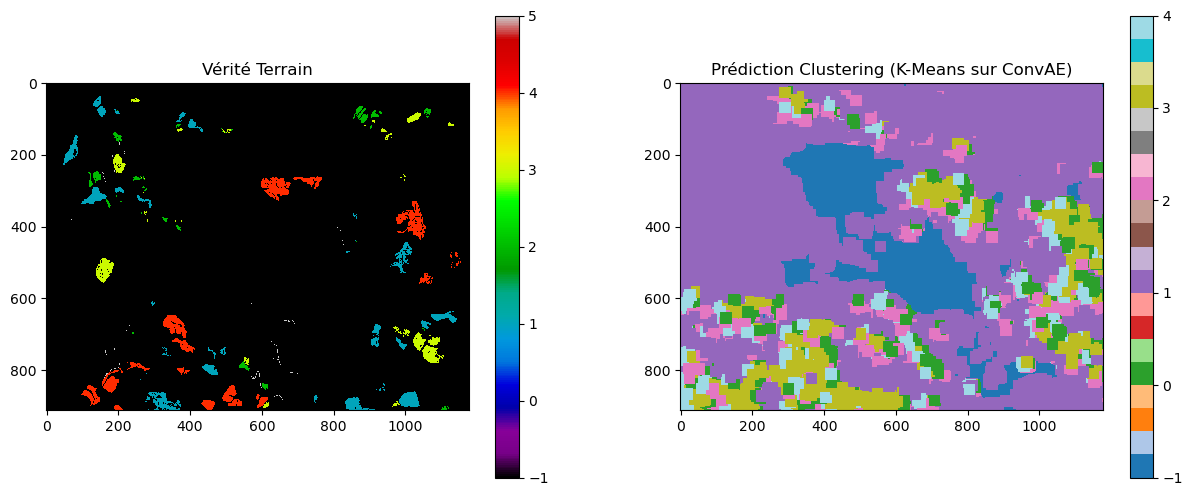

In [ ]:
plt.figure(figsize=(15, 6))

# 1. Vérité Terrain
plt.subplot(1, 2, 1)
plt.imshow(ground_truth_labels_image, cmap='nipy_spectral', interpolation='nearest')
plt.title("Vérité Terrain")
plt.colorbar()

display_cluster = X_cluster.copy()

plt.subplot(1, 2, 2)
plt.imshow(display_cluster, cmap='tab20', interpolation='nearest')
plt.title("Prédiction Clustering (K-Means sur ConvAE)")
plt.colorbar()

plt.show()

<div id="42"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.2 Soil

In [280]:
latent_vectors_soil, positions = train_Conv2D_autoencoder(
    EPOCHS,  
    PATCH_SIZE, STRIDE, BATCH_SIZE, 
    img_scaled_soil_complete, soil_mask_2d, MAX_BATCHES_PER_EPOCH=300
)

Utilization du device : cuda
Epoch 1/20 | Batches: 65 | Loss: 0.441355
Epoch 2/20 | Batches: 65 | Loss: 0.165921
Epoch 3/20 | Batches: 65 | Loss: 0.124250
Epoch 4/20 | Batches: 65 | Loss: 0.111684
Epoch 5/20 | Batches: 65 | Loss: 0.106577
Epoch 6/20 | Batches: 65 | Loss: 0.100119
Epoch 7/20 | Batches: 65 | Loss: 0.096110
Epoch 8/20 | Batches: 65 | Loss: 0.094648
Epoch 9/20 | Batches: 65 | Loss: 0.093325
Epoch 10/20 | Batches: 65 | Loss: 0.098251
Epoch 11/20 | Batches: 65 | Loss: 0.103301
Epoch 12/20 | Batches: 65 | Loss: 0.089930
Epoch 13/20 | Batches: 65 | Loss: 0.089843
Epoch 14/20 | Batches: 65 | Loss: 0.088452
Epoch 15/20 | Batches: 65 | Loss: 0.087874
Epoch 16/20 | Batches: 65 | Loss: 0.090309
Epoch 17/20 | Batches: 65 | Loss: 0.087688
Epoch 18/20 | Batches: 65 | Loss: 0.088407
Epoch 19/20 | Batches: 65 | Loss: 0.086797
Epoch 20/20 | Batches: 65 | Loss: 0.086224


In [281]:
labels_soil = KM_Silhouette(img_scaled_soil_complete.reshape(m,n,l), positions, latent_vectors_soil, optimal_k_soil, 10000)

Extraction des pixels physiques alignés...
Silhouette (échantillon) pour k = 15 : -0.049


<div id="43"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.3 Other

In [282]:
latent_vectors_other, positions = train_Conv2D_autoencoder(
    EPOCHS,  
    PATCH_SIZE, STRIDE, BATCH_SIZE, 
    img_scaled_other_complete, other_mask_2d, MAX_BATCHES_PER_EPOCH=300
)

Utilization du device : cuda
Epoch 1/20 | Batches: 58 | Loss: 0.442566
Epoch 2/20 | Batches: 58 | Loss: 0.142200
Epoch 3/20 | Batches: 58 | Loss: 0.114818
Epoch 4/20 | Batches: 58 | Loss: 0.103752
Epoch 5/20 | Batches: 58 | Loss: 0.099366
Epoch 6/20 | Batches: 58 | Loss: 0.095955
Epoch 7/20 | Batches: 58 | Loss: 0.095186
Epoch 8/20 | Batches: 58 | Loss: 0.093722
Epoch 9/20 | Batches: 58 | Loss: 0.091505
Epoch 10/20 | Batches: 58 | Loss: 0.090804
Epoch 11/20 | Batches: 58 | Loss: 0.089760
Epoch 12/20 | Batches: 58 | Loss: 0.089589
Epoch 13/20 | Batches: 58 | Loss: 0.089226
Epoch 14/20 | Batches: 58 | Loss: 0.087842
Epoch 15/20 | Batches: 58 | Loss: 0.087338
Epoch 16/20 | Batches: 58 | Loss: 0.086502
Epoch 17/20 | Batches: 58 | Loss: 0.085958
Epoch 18/20 | Batches: 58 | Loss: 0.085795
Epoch 19/20 | Batches: 58 | Loss: 0.085117
Epoch 20/20 | Batches: 58 | Loss: 0.085381


In [283]:
labels_other = KM_Silhouette(img_scaled_other_complete.reshape(m,n,l), positions, latent_vectors_other, optimal_k_other, 10000)

Extraction des pixels physiques alignés...
Silhouette (échantillon) pour k = 5 : 0.076


<div id="44"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.4 Nombre de clusters pour la végétation avec CDH

In [284]:
N = 20000
idx = np.random.choice(len(X_scaled_veg), N, replace=False)
X_sample = X_scaled_veg[idx]
X_sample_original = veg_pixels[idx]
#print(X_sample.shape)
#print(X_sample_original.shape)

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

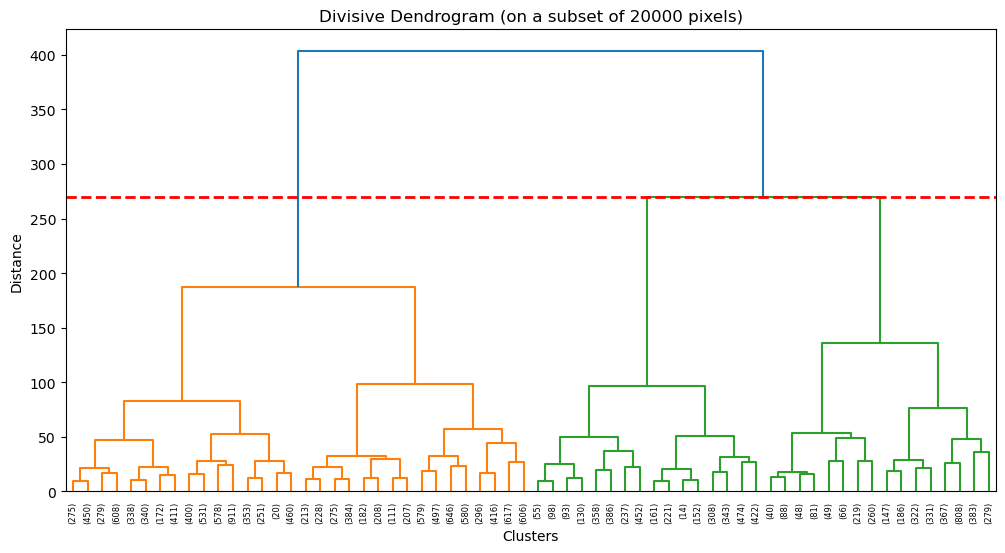

In [285]:
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Divisive Dendrogram (on a subset of 20000 pixels)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

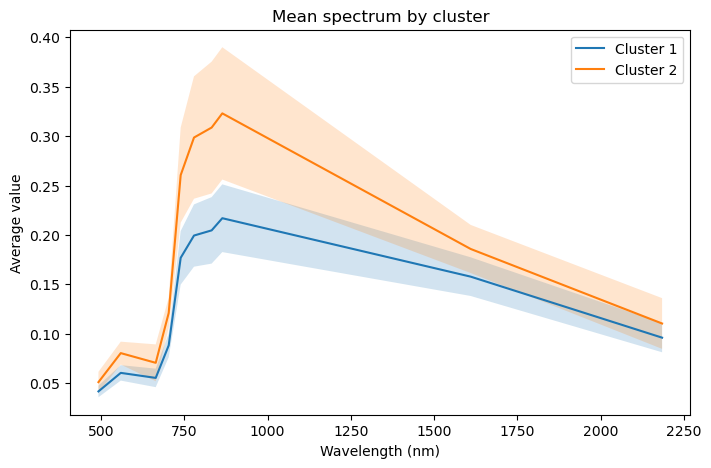

In [287]:
# img : (H, W, B)
# labels : (H, W) avec 0 ou 1

# Calcul des spectres moyens et écart-types
mean_spectra = []
std_spectra = []
valid_clusters = []

for k in np.unique(labels):
    pixels_k = X_sample_original[labels == k]  # extraire les pixels de la classe k
    if pixels_k.size == 0:
        continue  # ignorer les classes vides
    mean_spectra.append(pixels_k.mean(axis=0))
    std_spectra.append(pixels_k.std(axis=0))
    valid_clusters.append(k)

mean_spectra = np.array(mean_spectra)
std_spectra = np.array(std_spectra)
bands = np.array([492, 559, 664, 703, 739, 779, 832, 864, 1610, 2185])

# Affichage
plt.figure(figsize=(8,5))
for idx, k in enumerate(valid_clusters):
    plt.plot(bands, mean_spectra[idx], label=f'Cluster {k}')
    plt.fill_between(
        bands,
        mean_spectra[idx] - std_spectra[idx],
        mean_spectra[idx] + std_spectra[idx],
        alpha=0.2
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Average value')
plt.title('Mean spectrum by cluster')
plt.legend()
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> 
    <p style="margin-top: 5px; margin-bottom: 0;">
Divisive Hierarchical Clustering suggests to only keep two clusters. The mean spectrum shows that cluster one keeps a higher reflectance on all wavelengths, thus corresponding to sane, dense vegetation (forests). Cluster two, with lower reflectance, corresponds to more sparse vegetation (shrubs).

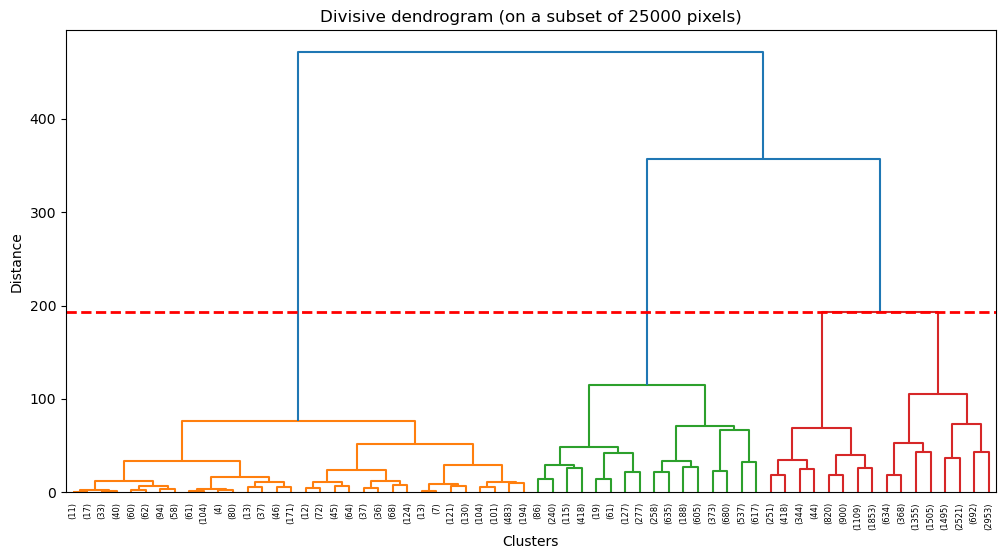

In [288]:
N = 25000
idx_selected = np.random.choice(len(X_scaled_other), N, replace=False)
X_sample = X_scaled_other[idx_selected]
X_sample_original = other_pixels[idx_selected]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Divisive dendrogram (on a subset of 25000 pixels)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()


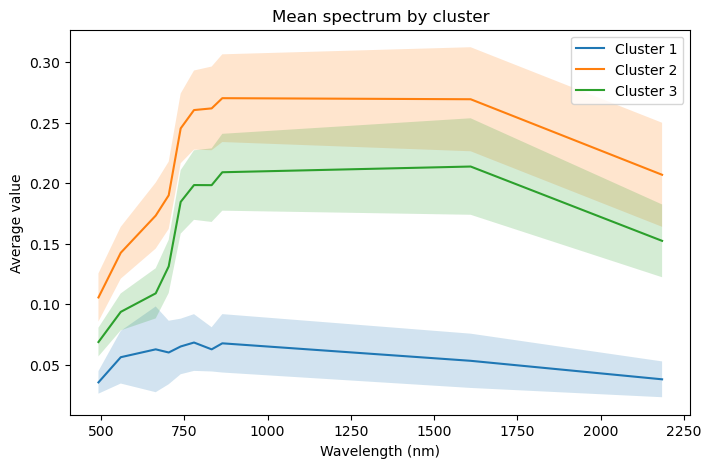

In [289]:
# img : (H, W, B)
# labels : (H, W) avec 0 ou 1

# Calcul des spectres moyens et écart-types
mean_spectra = []
std_spectra = []
valid_clusters = []

for k in np.unique(labels):
    pixels_k = X_sample_original[labels == k]  # extraire les pixels de la classe k
    if pixels_k.size == 0:
        continue  # ignorer les classes vides
    mean_spectra.append(pixels_k.mean(axis=0))
    std_spectra.append(pixels_k.std(axis=0))
    valid_clusters.append(k)

mean_spectra = np.array(mean_spectra)
std_spectra = np.array(std_spectra)
bands = np.array([492, 559, 664, 703, 739, 779, 832, 864, 1610, 2185])

# Affichage
plt.figure(figsize=(8,5))
for idx, k in enumerate(valid_clusters):
    plt.plot(bands, mean_spectra[idx], label=f'Cluster {k}')
    plt.fill_between(
        bands,
        mean_spectra[idx] - std_spectra[idx],
        mean_spectra[idx] + std_spectra[idx],
        alpha=0.2
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Average value')
plt.title('Mean spectrum by cluster')
plt.legend()
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> 
    <p style="margin-top: 5px; margin-bottom: 0;">
Divisive Hierarchical Clustering suggests to only keep three clusters. The mean spectrum shows that cluster one keeps a very low reflectance on all wavelengths : this is characteristic of water areas. Cluster two shows high values of reflectance on SWIR wavelengths, which could correspond to urban areas (building materials). Cluster three has a similar shape compared to cluster two but with higher reflectance values : it may also correspond to urban areas, but roads/asphalt spaces rather than buildings.

In [290]:
def display_clusters_subset(mask_2D, idx, labels, optimal_k):
    # --- 7) Construction de la carte finale ---
    cluster_map = np.zeros((m, n), dtype=int)

    indices = np.where(mask_2D.ravel())[0] # Indices 1D dans le tableau aplati
    indices_to_color = indices[idx]
    cluster_map.ravel()[indices_to_color] = labels + 1
    
    # --- 8) Création de la colormap ---
    cmap_colors = ["black"] + list(plt.cm.tab10.colors[:optimal_k])
    cmap = colors.ListedColormap(cmap_colors)
    
    # --- 9) Affichage ---
    plt.figure(figsize=(10,10))
    plt.imshow(cluster_map, cmap=cmap)
    plt.axis('off')
    #plt.title("Clusters of vegetation")
    plt.show()

In [ ]:
#display_clusters_subset(other_mask_2d, idx_selected, labels, np.unique(labels).shape[0])

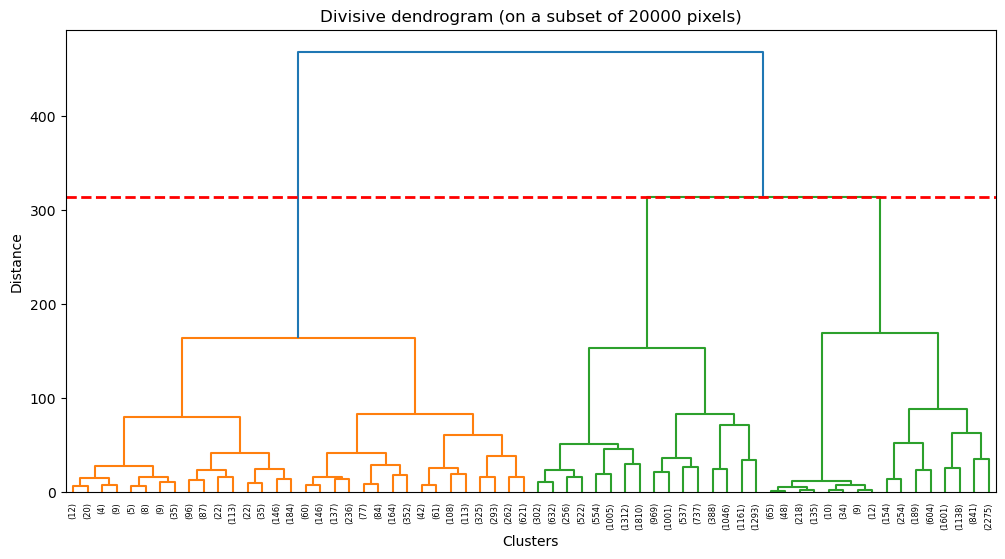

In [291]:
N = 25000
idx = np.random.choice(len(X_scaled_soil), N, replace=False)
X_sample = X_scaled_soil[idx]
X_sample_original = soil_pixels[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Divisive dendrogram (on a subset of 20000 pixels)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

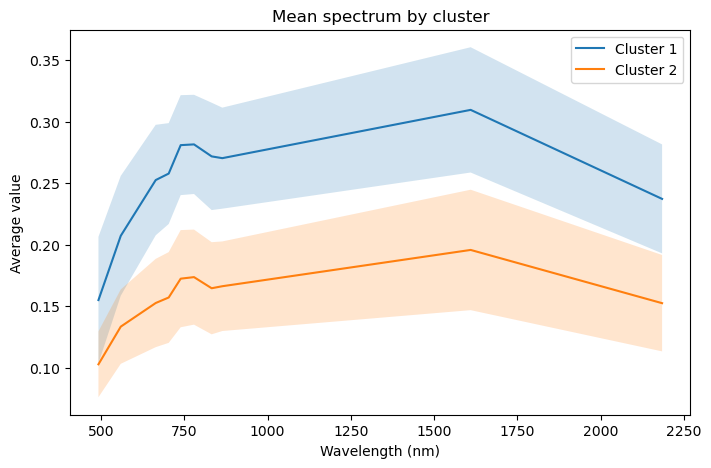

In [292]:
# img : (H, W, B)
# labels : (H, W) avec 0 ou 1

# Calcul des spectres moyens et écart-types
mean_spectra = []
std_spectra = []
valid_clusters = []

for k in np.unique(labels):
    pixels_k = X_sample_original[labels == k]  # extraire les pixels de la classe k
    if pixels_k.size == 0:
        continue  # ignorer les classes vides
    mean_spectra.append(pixels_k.mean(axis=0))
    std_spectra.append(pixels_k.std(axis=0))
    valid_clusters.append(k)

mean_spectra = np.array(mean_spectra)
std_spectra = np.array(std_spectra)
bands = np.array([492, 559, 664, 703, 739, 779, 832, 864, 1610, 2185])

# Affichage
plt.figure(figsize=(8,5))
for idx, k in enumerate(valid_clusters):
    plt.plot(bands, mean_spectra[idx], label=f'Cluster {k}')
    plt.fill_between(
        bands,
        mean_spectra[idx] - std_spectra[idx],
        mean_spectra[idx] + std_spectra[idx],
        alpha=0.2
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Average value')
plt.title('Mean spectrum by cluster')
plt.legend()
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> 
    <p style="margin-top: 5px; margin-bottom: 0;">
Divisive Hierarchical Clustering suggests to only keep two clusters. The mean spectrum shows that both clusters have similar shapes, but that cluster one has lower reflectance, which could be due to the presence of water. Thus, we can suggest that cluster one corresponds to wet soils (agricultural soils, loamy soils...) and cluster two to drier soil areas.

<div id="30"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    5. Deep Clustering

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> 
    <p style="margin-top: 5px; margin-bottom: 0;">
For deep clustering, we will select "valid" patches from the original image and train an Autoencoder on those patches. Then we will train a clustering layer on the outputs of Autoencoder that will force separation between the clusters.

In [298]:
# ==========================================
# 1. PARAMÈTRES ET CONFIGURATION
# ==========================================
PATCH_SIZE = 5  # Réduire taille patch : 16*16, 9*9
STRIDE = 3 # Pour l'apprentissage, pas le test !
BATCH_SIZE = 512
LATENT_DIM = 4
N_CLUSTERS = 5
MIN_VALID_RATIO = 0.8
LAMBDA = 0.1
N_EPOCHS_AE = 25
N_EPOCHS_CLUSTERING = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil : {device}")

Utilisation de l'appareil : cuda


In [293]:
class ConvAutoencoder_forDC(nn.Module):
    def __init__(self, in_channels, latent_dim):
        """
        in_channels : nombre de canaux de l'image
        latent_dim  : taille du vecteur latent
        input_size  : taille de l'image d'entrée (supposé carré)
        """
        super(ConvAutoencoder_forDC, self).__init__()

        self.latent_dim = latent_dim

        # ------- ENCODER -------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, stride=1, padding=0),  # H/2
            nn.GroupNorm(8, 64),
            nn.ReLU(True),

            nn.Conv2d(64, 128, 3, stride=1, padding=0),           # H/4
            #nn.InstanceNorm2d(64, affine=True),
            nn.ReLU(True),
            #ResidualBlock(64),  # Residual pour enrichir la représentation

        )
        
         # PAS de pooling global
        self.flatten = nn.Flatten()
        self.fc_enc = nn.Linear(128, self.latent_dim)  # on initialisera dynamiquement au premier forward
        self.fc_dec = nn.Linear(self.latent_dim, 128)

        # ------- DECODER -------
        self.decoder_conv = nn.Sequential(

            nn.ConvTranspose2d(128, 64, 3, stride=1, padding=0),
            nn.GroupNorm(8, 64),
            nn.ReLU(True),
            #ResidualBlock(128),

            nn.ConvTranspose2d(64, in_channels, 3, stride=1, padding=0),  # H*2
            #nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        z = self.fc_enc(self.flatten(h))
        return z

    def forward(self, x):
        # Encoder
        z_latent = self.encode(x)                # Latent vector

        # Decoder
        z_dec = self.fc_dec(z_latent)
        z_dec = z_dec.view(-1, 128, 1, 1)
        x_recon = self.decoder_conv(z_dec)

        return x_recon, z_latent

In [294]:
class DeepClusteringDataset(Dataset):
    def __init__(self, img_tensor, mask_tensor, patch_size, stride, min_valid_ratio):
        self.img_tensor = img_tensor
        self.mask_tensor = mask_tensor
        self.patch_size = patch_size
        
        # On utilise l'optimisation par convolution pour lister les positions valides dès le départ
        self.positions = self._get_valid_indices(mask_tensor, patch_size, stride, min_valid_ratio)
        
    def _get_valid_indices(self, mask_tensor, patch_size, stride, min_valid_ratio):
        mask_4d = mask_tensor.unsqueeze(0).unsqueeze(0).float()
        kernel = torch.ones((1, 1, patch_size, patch_size))
        valid_sums = torch.nn.functional.conv2d(mask_4d, kernel, stride=stride)
        valid_ratios = valid_sums / (patch_size * patch_size)
        indices = (valid_ratios >= min_valid_ratio).nonzero(as_tuple=False)
        return [(idx[2].item() * stride, idx[3].item() * stride) for idx in indices]

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, idx):
        i, j = self.positions[idx]
        patch = self.img_tensor[:, i:i+self.patch_size, j:j+self.patch_size].clone()
        mask_patch = self.mask_tensor[i:i+self.patch_size, j:j+self.patch_size].clone()

        # On retourne le patch et le masque
        return patch, mask_patch

In [295]:
# 1. Conversion explicite en Tenseurs PyTorch
# .float() est nécessaire pour la convolution plus bas
img_veg_torch = torch.from_numpy(img_scaled_veg_complete.reshape(n,m,l).T).float()
mask_veg_torch = torch.from_numpy(veg_mask_2d).float()

#print(veg_mask_2d.shape)

# 1. Instanciation du Dataset
veggie_ds = DeepClusteringDataset(
    img_tensor=img_veg_torch, 
    mask_tensor=mask_veg_torch, 
    patch_size=PATCH_SIZE, 
    stride=STRIDE, 
    min_valid_ratio=MIN_VALID_RATIO
)

# 2. Création du DataLoader compatible avec le script d'entraînement
dataloader_veg = DataLoader(
    veggie_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True,      # Mélange les patchs à chaque époque
    num_workers=0,     # Accélère le chargement via CPU multi-threading
    pin_memory=True,    # Accélère le transfert vers le GPU
    persistent_workers = False
)

In [296]:
class DeepClusteringWrapper(nn.Module):
    def __init__(self, autoencoder, n_clusters=N_CLUSTERS, latent_dim=LATENT_DIM, alpha=1.0):
        super(DeepClusteringWrapper, self).__init__()
        self.ae = autoencoder
        self.alpha = alpha
        # Centres des clusters (seront initialisés par K-Means)
        self.centroids = nn.Parameter(torch.zeros(n_clusters, latent_dim))

    def forward(self, x):
        # On utilise ta méthode .encode()
        z = self.ae.encode(x)
        z = F.normalize(z, dim=1)   # ← AJOUT MINIMAL
        centroids = F.normalize(self.centroids, dim=1)

        # Calcul de la distribution Q (Soft Assignment) basé sur t-Student
        q = 1.0 / (1.0 + torch.sum((z.unsqueeze(1) - centroids)**2, 2) / self.alpha)
        q = q**((self.alpha + 1.0) / 2.0)
        q = (q.t() / (torch.sum(q, 1) + 1e-8)).t()
        return z, q

    @staticmethod
    def target_distribution(q):
        """Calcule la distribution cible P pour 'durcir' les clusters"""
        weight = q**2 / (q.sum(0) + 1e-8)
        return (weight.t() / (weight.sum(1)+1e-8)).t()

In [297]:
def train_model(autoencoder, dataloader, NEPOCHS_ae, NEPOCHS_clustering, n_clusters, latent_dim):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    autoencoder.to(device)
    
    # --- ÉTAPE 1 : PRÉ-ENTRAÎNEMENT (Apprendre les textures) ---
    # On entraîne l'AE à reconstruire les patchs de végétation
    print("Phase 1 : Pré-entraînement de l'Autoencodeur...")
    optimizer_ae = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

    # Utilisation du scaler pour le Mixed Precision (vitesse ++ sur RTX 5060)
    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(NEPOCHS_ae): # Ajustable
        autoencoder.train()
        total_loss = 0
        for data, masks in dataloader:
            data = data.to(device, non_blocking = True)
            masks = masks.to(device, non_blocking=True).float() 

            masks = masks.unsqueeze(1)

            masks_expanded = masks.expand_as(data)

            with torch.no_grad():
                # Somme des pixels valides par canal / nombre de pixels valides
                sum_val = (data * masks_expanded).sum(dim=(2, 3), keepdim=True)
                count_val = masks_expanded.sum(dim=(2, 3), keepdim=True) + 1e-8
                mean_patch = sum_val / count_val
                
                # On remplace les 0 par la moyenne + un micro-bruit (0.01) pour la texture
                noise = torch.randn_like(data) * 0.01
                data_filled = torch.where(masks_expanded == 1, data, mean_patch + noise)

            """
                    # AUGMENTATION : Flip Aléatoire (Horizontal & Vertical)
            if np.random.rand() > 0.5:
                k = np.random.randint(1, 4)
                data = torch.rot90(data, k, dims=[2, 3])
                masks = torch.rot90(masks, k, dims=[2, 3])
            """

            with torch.amp.autocast('cuda'): # Accélère le calcul sur Blackwell
                recon, _ = autoencoder(data_filled)
                # --- CALCUL DE LA MSE MASQUÉE ---
            # On multiplie l'erreur par le masque pour annuler les pixels invalides
                squared_diff = (recon - data) ** 2

                masked_error = squared_diff * masks_expanded

                # Moyenne uniquement sur les pixels valides
                loss = masked_error.sum() / (masks_expanded.sum() + 1e-8)
            
            optimizer_ae.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer_ae)
            scaler.update()

            total_loss += loss.item()
        print(f"Epoch {epoch+1} - MSE Loss: {total_loss/len(dataloader):.6f}")

    # --- ÉTAPE 2 : INITIALISATION DES CENTRES ---
    print("\nPhase 2 : Initialisation des clusters avec K-Means...")
    autoencoder.eval()
    all_z = []
    with torch.no_grad():
        for data, masks in dataloader:
            # On utilise aussi l'imputation pour l'encodage final avant K-means
            data = data.to(device)
            masks = masks.to(device).float()
            masks = masks.unsqueeze(1)
            masks_exp = masks.to(device).expand_as(data.to(device))
            m_patch = (data.to(device) * masks_exp).sum(dim=(2,3), keepdim=True) / (masks_exp.sum(dim=(2,3), keepdim=True) + 1e-8)
            d_filled = torch.where(masks_exp == 1, data, m_patch)
            z = autoencoder.encode(d_filled)
            all_z.append(z.cpu().numpy())
    
    all_z = np.concatenate(all_z, axis = 0)
    kmeans = KMeans(n_clusters=n_clusters, n_init=100, random_state=0)
    kmeans.fit(all_z)

    counts = np.bincount(kmeans.labels_)
    print(f"Répartition initiale K-Means : {counts}")
    
    # Création du modèle DEC complet
    model = DeepClusteringWrapper(autoencoder, n_clusters, latent_dim).to(device)
    model.centroids.data = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32).to(device)

    # --- ÉTAPE 3 : RAFFINEMENT (Deep Clustering) ---
    # Avant la Phase 3
    # 1. On crée un dataloader SANS shuffle pour garantir l'ordre des indices
    dataloader_fixed = DataLoader(
        dataloader.dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=False,  # <--- CRUCIAL : l'ordre ne change plus
        num_workers=dataloader.num_workers,
        pin_memory=True
    )
    print("\nPhase 3 : Raffinement par divergence KL...")
    # On utilise souvent un LR plus faible et SGD pour la stabilité du clustering
    # --- PHASE 3 : Optimisation Asymétrique ---
    optimizer_dec = torch.optim.Adam([
        # On bride l'autoencodeur pour protéger les textures
        {'params': model.ae.parameters(), 'lr': 1e-6}, 
        
        # On laisse les centroïdes s'ajuster aux données
        {'params': model.centroids, 'lr': 1e-4}
    ])
    criterion_kl = nn.KLDivLoss(reduction='batchmean')

    for epoch in range(NEPOCHS_clustering):
        model.eval()

        all_q = []
        with torch.no_grad():
            for data, masks in dataloader_fixed:
                masks = masks.unsqueeze(1)
                masks_exp = masks.to(device).expand_as(data.to(device))
                m_patch = (data.to(device) * masks_exp).sum(dim=(2,3), keepdim=True) / (masks_exp.sum(dim=(2,3), keepdim=True) + 1e-8)
                d_filled = torch.where(masks_exp == 1, data.to(device), m_patch)
                _, q = model(d_filled)
                all_q.append(q.cpu())
        
        all_q = torch.cat(all_q, dim=0)
        all_p = model.target_distribution(all_q).detach()

        model.train()
        total_kl, total_mse = 0, 0
        cursor = 0 # Pour suivre la position dans all_p
        
        for data, masks in dataloader_fixed:
            data = data.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True).float()
            masks = masks.unsqueeze(1)
            
            # Extraction de la cible correspondante au batch
            current_batch_size = data.size(0)
            p_batch = all_p[cursor:cursor+current_batch_size].to(device)
            cursor += current_batch_size

            # Note : Pas d'autocast ici pour la précision de la divergence KL
            z, q = model(data)
            
            # 3. Minimiser KL(P || Q)
            loss_kl = criterion_kl((q+1e-10).log(), p_batch)

                        # On force le décodeur à toujours savoir reconstruire le patch
            recon, _ = model.ae(data)
            squared_diff = (recon - data)**2
            masks_expanded = masks.expand_as(data)
            loss_mse = (squared_diff * masks_expanded).sum() / (masks_expanded.sum() + 1e-8)

            # Perte combinée
            total_loss = loss_kl + LAMBDA * loss_mse 
            
            optimizer_dec.zero_grad()
            total_loss.backward()
            optimizer_dec.step()
            total_kl += loss_kl.item()
            total_mse += loss_mse.item()
            
        print(f"Epoch {epoch+1} - KL: {total_kl/len(dataloader):.6f} | MSE: {total_mse/len(dataloader):.6f}")
    
    return model

In [299]:
CHANNELS = 10 # Nombre de bandes (ex: 3 pour RGB, 4 pour RGB-NIR)
ae = ConvAutoencoder_forDC(in_channels=CHANNELS, latent_dim=LATENT_DIM)

In [300]:
model_final = train_model(
    ae, 
    dataloader_veg, 
    N_EPOCHS_AE,           # Phase de reconstruction
    N_EPOCHS_CLUSTERING,   # Phase de raffinement des clusters
    N_CLUSTERS,
    LATENT_DIM
)

# Sauvegarde du modèle pour ne pas perdre l'apprentissage
torch.save(model_final.state_dict(), "dec_model_vegetation.pth")
print("Modèle entraîné et sauvegardé !")

Phase 1 : Pré-entraînement de l'Autoencodeur...
Epoch 1 - MSE Loss: 0.364575
Epoch 2 - MSE Loss: 0.277136
Epoch 3 - MSE Loss: 0.255272
Epoch 4 - MSE Loss: 0.244864
Epoch 5 - MSE Loss: 0.239910
Epoch 6 - MSE Loss: 0.235921
Epoch 7 - MSE Loss: 0.233519
Epoch 8 - MSE Loss: 0.231030
Epoch 9 - MSE Loss: 0.229075
Epoch 10 - MSE Loss: 0.227914
Epoch 11 - MSE Loss: 0.226182
Epoch 12 - MSE Loss: 0.224875
Epoch 13 - MSE Loss: 0.224436
Epoch 14 - MSE Loss: 0.223326
Epoch 15 - MSE Loss: 0.222437
Epoch 16 - MSE Loss: 0.221561
Epoch 17 - MSE Loss: 0.220816
Epoch 18 - MSE Loss: 0.220489
Epoch 19 - MSE Loss: 0.219831
Epoch 20 - MSE Loss: 0.219216
Epoch 21 - MSE Loss: 0.218724
Epoch 22 - MSE Loss: 0.218093
Epoch 23 - MSE Loss: 0.217898
Epoch 24 - MSE Loss: 0.217140
Epoch 25 - MSE Loss: 0.216550

Phase 2 : Initialisation des clusters avec K-Means...
Répartition initiale K-Means : [45324  5165  5136  7758  2325]

Phase 3 : Raffinement par divergence KL...
Epoch 1 - KL: 0.037624 | MSE: 0.108397
Epoch 2 - 

Extraction des caractéristiques latentes...
Calcul du t-SNE (cela peut prendre une minute)...


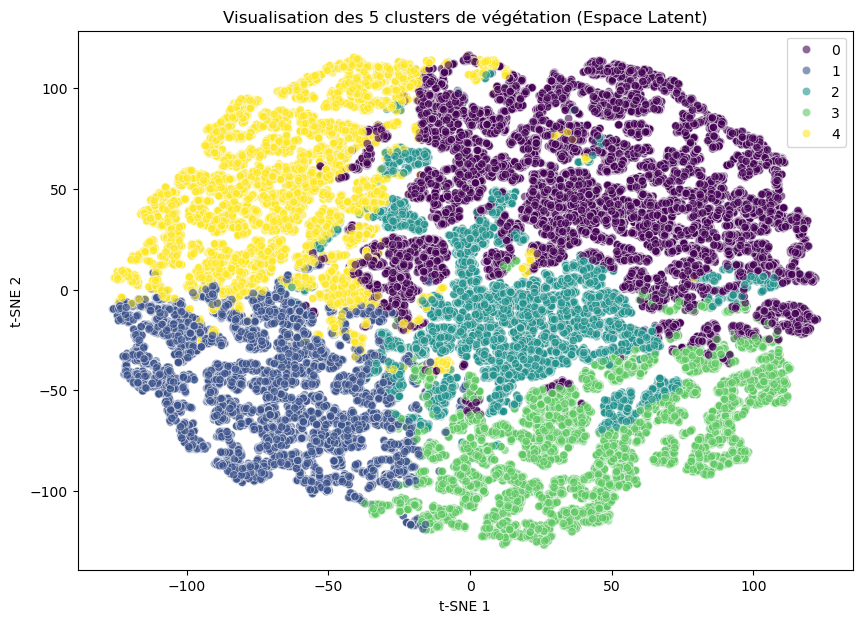

In [301]:
def plot_clusters(model, dataloader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    latent_features = []
    labels = []
    
    print("Extraction des caractéristiques latentes...")
    with torch.no_grad():
        for data, _ in dataloader:
            data = data.to(device)
            z, q = model(data)
            
            # On prend le cluster avec la probabilité la plus haute
            cluster_preds = torch.argmax(q, dim=1)
            
            latent_features.append(z.cpu().numpy())
            labels.append(cluster_preds.cpu().numpy())
            
    latent_features = np.concatenate(latent_features, axis=0)
    labels = np.concatenate(labels, axis=0)
    
    # Réduction de dimension t-SNE (64D -> 2D)
    print("Calcul du t-SNE (cela peut prendre une minute)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    z_2d = tsne.fit_transform(latent_features)
    
    # Affichage
    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=z_2d[:,0], y=z_2d[:,1], hue=labels, palette='viridis', legend='full', alpha=0.6)
    plt.title(f"Visualisation des {len(np.unique(labels))} clusters de végétation (Espace Latent)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.show()

# Utilisation :
plot_clusters(model_final, dataloader_veg)

In [ ]:
"""

def generate_voted_vegetation_map(model, img_tensor, mask_tensor, n_clusters=N_CLUSTERS, patch_size=PATCH_SIZE, stride=STRIDE):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    C, H, W = img_tensor.shape
    vote_cube = np.zeros((n_clusters, H, W), dtype=np.uint16)

    print("Génération de la carte filtrée par le masque de végétation...")
    with torch.no_grad():
        for i in range(0, H - patch_size + 1, stride):
            for j in range(0, W - patch_size + 1, stride):
                
                patch = img_tensor[:, i:i+patch_size, j:j+patch_size].unsqueeze(0).to(device)
                _, q = model(patch)
                cluster_idx = torch.argmax(q, dim=1).item()
                
                # On vote
                vote_cube[cluster_idx, i:i+patch_size, j:j+patch_size] += 1

    # Application du vote majoritaire
    final_map = np.argmax(vote_cube, axis=0).astype(np.uint8)
    
    # APPLICATION DU MASQUE FINAL : 
    # Tous les pixels qui ne sont pas de la végétation dans le masque original (ex: valeur 0)
    # reçoivent une valeur de "No Data" (ex: 255)
    final_map[mask_tensor == 0] = 255 
    
    return final_map

# Exécution avec votre masque original
map_vegetation_pure = generate_voted_vegetation_map(
    model_final, 
    img_veg_torch, 
    mask_veg_torch, # Votre masque 2D de végétation
    n_clusters=5
)

"""

'\n\ndef generate_voted_vegetation_map(model, img_tensor, mask_tensor, n_clusters=N_CLUSTERS, patch_size=PATCH_SIZE, stride=STRIDE):\n    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n    model.eval()\n\n    C, H, W = img_tensor.shape\n    vote_cube = np.zeros((n_clusters, H, W), dtype=np.uint16)\n\n    print("Génération de la carte filtrée par le masque de végétation...")\n    with torch.no_grad():\n        for i in range(0, H - patch_size + 1, stride):\n            for j in range(0, W - patch_size + 1, stride):\n\n                patch = img_tensor[:, i:i+patch_size, j:j+patch_size].unsqueeze(0).to(device)\n                _, q = model(patch)\n                cluster_idx = torch.argmax(q, dim=1).item()\n\n                # On vote\n                vote_cube[cluster_idx, i:i+patch_size, j:j+patch_size] += 1\n\n    # Application du vote majoritaire\n    final_map = np.argmax(vote_cube, axis=0).astype(np.uint8)\n\n    # APPLICATION DU MASQUE FINAL : \n    # Tous

In [ ]:
"""

def generate_smooth_map(model, img_tensor, mask_tensor, patch_dataset, n_clusters=N_CLUSTERS, patch_size=PATCH_SIZE, stride=STRIDE):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    C, H, W = img_tensor.shape
    # Accumulateur de probabilités (au lieu de votes entiers)
    score_map = np.zeros((n_clusters, H, W), dtype=np.float32)
    # Accumulateur de poids (pour normaliser les zones où les patchs se chevauchent)
    weight_sum = np.zeros((H, W), dtype=np.float32)
    
    # 1. Création d'une fenêtre de pondération (Gaussienne 2D)
    # Cela donne plus de poids au centre du patch pour éviter les effets de bordure
    def gaussian_2d(shape, sigma=1):
        m, n = [(ss - 1.) / 2. for ss in shape]
        y, x = np.ogrid[-m:m + 1, -n:n + 1]
        h = np.exp(-(x * x + y * y) / (2. * sigma * sigma))
        return h / h.max()

    window = gaussian_2d((patch_size, patch_size), sigma=patch_size/2)

    print("Génération de la carte lisse par pondération gaussienne...")
    with torch.no_grad():
        for (i, j) in patch_dataset.positions :
                
            patch = img_tensor[:, i:i+patch_size, j:j+patch_size].unsqueeze(0).to(device)
            _, q = model(patch) # q est la distribution de probabilité (Batch, 5)
                
                # On distribue les probabilités sur toute la surface du patch 
                # multipliées par le poids de la fenêtre
            q_values = q.squeeze(0).cpu().numpy() # Shape (5,)
            for c in range(n_clusters):
                score_map[c, i:i+patch_size, j:j+patch_size] += q_values[c] * window

                # On garde trace du cumul des poids pour la normalisation finale
            weight_sum[i:i+patch_size, j:j+patch_size] += window

    valid_mask = weight_sum > 0
    for k in range(n_clusters):
        score_map[k][valid_mask] /= weight_sum[valid_mask]

        # 2. Election finale par Argmax sur les scores accumulés
    final_map = np.argmax(score_map, axis=0).astype(float)

    # 3. Pixels hors patch valide → -1
    final_map[weight_sum == 0] = -1

    # 4. Application du masque noir (hors végétation)
    final_map[mask_tensor.cpu().numpy() == 0] = -1
    
    return final_map

map_vegetation_pure = generate_smooth_map(
    model_final, 
    img_veg_torch, 
    mask_veg_torch, # Votre masque 2D de végétation
    veggie_ds,
    stride=4
)

"""

'\n\ndef generate_smooth_map(model, img_tensor, mask_tensor, patch_dataset, n_clusters=N_CLUSTERS, patch_size=PATCH_SIZE, stride=STRIDE):\n    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n    model.eval()\n\n    C, H, W = img_tensor.shape\n    # Accumulateur de probabilités (au lieu de votes entiers)\n    score_map = np.zeros((n_clusters, H, W), dtype=np.float32)\n    # Accumulateur de poids (pour normaliser les zones où les patchs se chevauchent)\n    weight_sum = np.zeros((H, W), dtype=np.float32)\n\n    # 1. Création d\'une fenêtre de pondération (Gaussienne 2D)\n    # Cela donne plus de poids au centre du patch pour éviter les effets de bordure\n    def gaussian_2d(shape, sigma=1):\n        m, n = [(ss - 1.) / 2. for ss in shape]\n        y, x = np.ogrid[-m:m + 1, -n:n + 1]\n        h = np.exp(-(x * x + y * y) / (2. * sigma * sigma))\n        return h / h.max()\n\n    window = gaussian_2d((patch_size, patch_size), sigma=patch_size/2)\n\n    print("Générati

In [302]:
def generate_map_batch_central(model, img_tensor, mask_tensor, patch_size=PATCH_SIZE, batch_size=BATCH_SIZE):
    """
    Génère la carte de clusters en assignant à chaque pixel central la classe de son patch.
    Utilise le GPU en mode batch pour la rapidité.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    # S'assurer que l'entrée est un tenseur PyTorch pour le slicing rapide
    if isinstance(img_tensor, np.ndarray):
        img_tensor = torch.from_numpy(img_tensor).float()
    if isinstance(mask_tensor, np.ndarray):
        mask_tensor = torch.from_numpy(mask_tensor).float()
    
    C, H, W = img_tensor.shape
    offset = patch_size // 2
    
    # Carte de sortie initialisée à -1 (fond/invalide)
    final_map = np.full((H, W), -1, dtype=np.int8)
    
    # On liste toutes les coordonnées (i, j) des coins supérieurs gauches valides
    # Un coin est valide si son pixel central correspondant n'est pas masqué
    print("Calcul des coordonnées valides...")
    valid_coords = []
    for i in range(H - patch_size + 1):
        for j in range(W - patch_size + 1):
            if mask_tensor[i + offset, j + offset] == 1:
                valid_coords.append((i, j))
    
    print(f"Nombre de patchs à traiter : {len(valid_coords)}")
    
    # Traitement par batchs
    with torch.no_grad():
        for b in tqdm(range(0, len(valid_coords), batch_size)):
            batch_indices = valid_coords[b : b + batch_size]
            
            # Préparation du batch de patchs
            patch_list = []
            for i, j in batch_indices:
                patch = img_tensor[:, i:i+patch_size, j:j+patch_size]
                patch_list.append(patch)
            
            # Transfert groupé sur GPU
            batch_tensor = torch.stack(patch_list).to(device)
            
            # Inférence DEC
            # On passe par l'imputation rapide si nécessaire ou directement
            # Si vous avez des pixels invalides INTERNES au patch, appliquez le remplissage ici
            _, q = model(batch_tensor)
            clusters = torch.argmax(q, dim=1).cpu().numpy()
            
            # Assignation des résultats aux pixels centraux
            for idx, (i, j) in enumerate(batch_indices):
                final_map[i + offset, j + offset] = clusters[idx]
                
    return final_map

(1074336, 10)
Calcul des coordonnées valides...
Nombre de patchs à traiter : 660544


100%|██████████| 1291/1291 [00:15<00:00, 82.34it/s] 


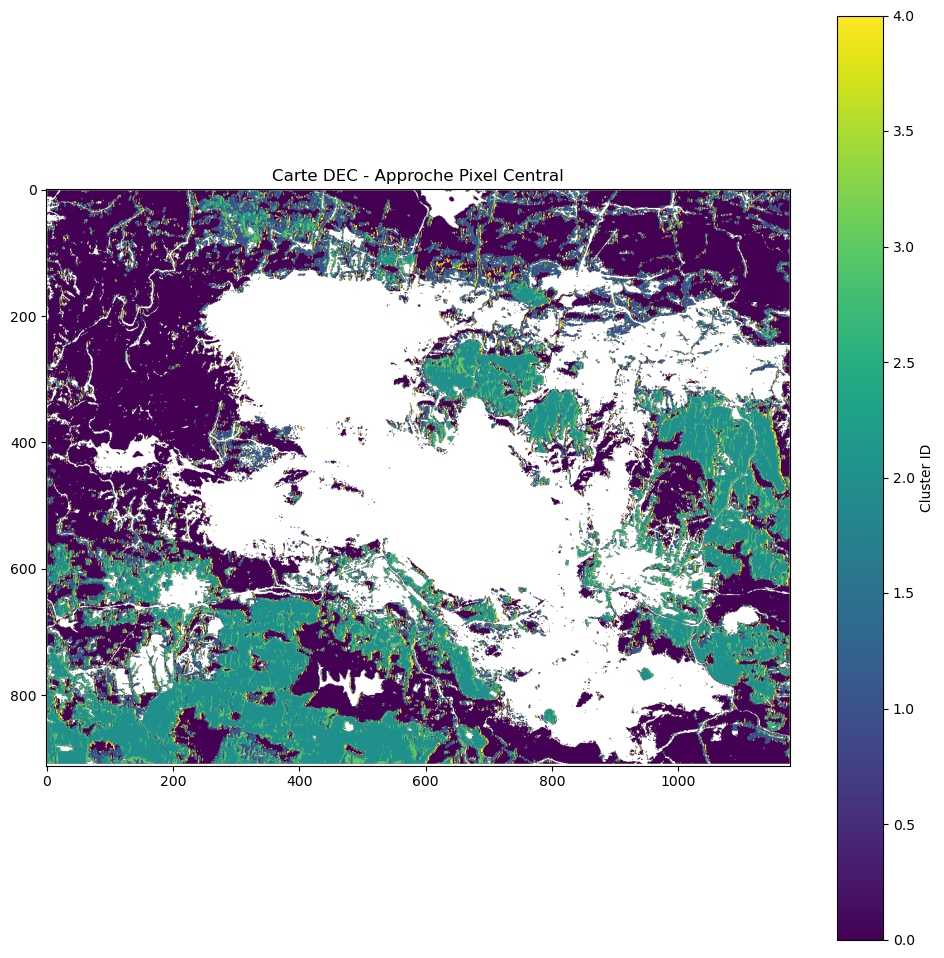

In [303]:
print(img_scaled_veg_complete.shape)

final_map = generate_map_batch_central(model_final, img_scaled_veg_complete.T.reshape(-1,m,n), veg_mask_2d)

# On masque les valeurs -1 pour l'affichage
display_map = np.ma.masked_where(final_map == -1, final_map)

plt.figure(figsize=(12, 12))
plt.imshow(display_map, cmap='viridis') # Ou 'terrain' pour la végétation
plt.colorbar(label='Cluster ID')
plt.title("Carte DEC - Approche Pixel Central")
plt.show()

In [ ]:
def Silhouette(img_2d, positions, latent_vectors, n_clusters, max_samples, labels):

    X_phys_aligned = []

    # Échantillonnage pour le score (car trop lourd sur tous les pixels)
    if latent_vectors.shape[0] > max_samples:
        idx = np.random.choice(latent_vectors.shape[0], max_samples, replace=False)
        labels_sample = labels[idx]
    else:
        labels_sample = labels

    print("Extraction des pixels physiques alignés...")
    for id in idx:
        # C'est ICI que se joue l'alignement
        r, c = positions[id] 
        
        # On récupère la valeur du pixel à cette coordonnée précise
        pixel_val = img_2d[r, c, :] 
        X_phys_aligned.append(pixel_val)

    X_phys_aligned = np.array(X_phys_aligned)

    sil_score = silhouette_score(X_phys_aligned, labels_sample)

    print(f"Silhouette (échantillon) pour k = {n_clusters} : {sil_score:.3f}")

    return labels

In [ ]:
"""

def plot_final_map_with_mask(clustered_map, mask_2d, n_clusters=N_CLUSTERS):
    #Affiche la carte de segmentation avec les pixels invalides en noir.
    plt.figure(figsize=(14, 10))
    
    # 1. Préparation des données : on crée une copie pour ne pas modifier l'original
    display_map = clustered_map.copy().astype(float)
    
    # 2. On utilise le masque binaire pour forcer les zones hors-végétation à -1
    # Assurez-vous que mask_2d a les mêmes dimensions que clustered_map
    display_map[mask_2d == 0] = -1
    
    # 3. Création d'une colormap personnalisée : Noir pour -1, Viridis pour 0-4
    # On récupère 5 couleurs de la palette viridis
    viridis_colors = cm.get_cmap('viridis', n_clusters)(np.linspace(0, 1, n_clusters))
    
    # On ajoute le noir (RGB 0,0,0) au début de la liste des couleurs
    black_color = np.array([[0, 0, 0, 1]]) 
    new_colors = np.vstack([black_color, viridis_colors])
    custom_cmap = ListedColormap(new_colors)

    # 4. Affichage
    # vmin=-1 permet de caler le noir sur la valeur -1
    im = plt.imshow(display_map, cmap=custom_cmap, vmin=-1, vmax=n_clusters-1)
    
    # 5. Configuration de la barre de légende
    # On définit les ticks pour inclure "Invalide"
    ticks = np.arange(-1, n_clusters)
    cbar = plt.colorbar(im, ticks=ticks)
    cbar.set_label('Classes de la carte')
    
    # Étiquettes de la légende
    labels = ['Hors-Végétation (Noir)'] + [f'Cluster {i}' for i in range(n_clusters)]
    cbar.ax.set_yticklabels(labels)

    plt.title("Carte Finale de Segmentation de la Végétation (DEC)\nPixels invalides en noir")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Appel de la fonction
# Note : passez bien votre masque binaire (veg_mask_2d ou mask_torch) en deuxième argument
plot_final_map_with_mask(map_vegetation_pure, veg_mask_2d, n_clusters=5)

"""

'\n\ndef plot_final_map_with_mask(clustered_map, mask_2d, n_clusters=N_CLUSTERS):\n    #Affiche la carte de segmentation avec les pixels invalides en noir.\n    plt.figure(figsize=(14, 10))\n\n    # 1. Préparation des données : on crée une copie pour ne pas modifier l\'original\n    display_map = clustered_map.copy().astype(float)\n\n    # 2. On utilise le masque binaire pour forcer les zones hors-végétation à -1\n    # Assurez-vous que mask_2d a les mêmes dimensions que clustered_map\n    display_map[mask_2d == 0] = -1\n\n    # 3. Création d\'une colormap personnalisée : Noir pour -1, Viridis pour 0-4\n    # On récupère 5 couleurs de la palette viridis\n    viridis_colors = cm.get_cmap(\'viridis\', n_clusters)(np.linspace(0, 1, n_clusters))\n\n    # On ajoute le noir (RGB 0,0,0) au début de la liste des couleurs\n    black_color = np.array([[0, 0, 0, 1]]) \n    new_colors = np.vstack([black_color, viridis_colors])\n    custom_cmap = ListedColormap(new_colors)\n\n    # 4. Affichage\n  